# Lab Assignment Three: Extending Logistic Regression

**Team Members:** Jadon Swearingen, Andy Su, Emilio Munoz

In this lab, we compare the performance of logistic regression optimization programmed in scikit-learn and via our own implementation. We also modify the optimization procedure for logistic regression.

**Dataset:** [Diabetes Health Indicators Dataset](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset?resource=download) — `diabetes_012_health_indicators_BRFSS2015.csv`

**Classification Task:** Multi-class classification (3 classes: 0 = No Diabetes, 1 = Prediabetes, 2 = Diabetes)

---
## 1. Setup and Imports

In [1]:
# Core packages
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import time
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)


---
## 2. Preparation and Overview (3 points total)

### 2.1 Business Understanding and Task Overview [2 points]

**Dataset Overview:**

This dataset is from the CDC's Behavioral Risk Factor Surveillance System (BRFSS) 2015 survey, which is a massive phone survey the CDC runs every year to track health trends across the US. It has 253,680 responses with 21 features covering things like BMI, blood pressure, smoking habits, income, age, etc.

**Classification Task:**

We're doing 3 class classification on the Diabetes_012 column: 0 = no diabetes, 1 = prediabetes, 2 = diabetes. The idea is to predict which category someone falls into based on their survey responses.

**Business Case / Use-Case:**

The point is to catch people who might be prediabetic or diabetic early using basic health info that's already collected in routine checkups or surveys. If you can flag someone as at risk before they even get a formal diagnosis, doctors can intervene sooner with lifestyle recommendations or monitoring.

For this algorithm to be useful to healthcare providers and insurance companies, we would need sensitivity (recall) >= 85 percent, as missing diabetic patients could have severe health consequences. We would need the overall accuracy to be more than 75%, to make it competitive with existing tools. We would want to have precision >= 60%.


**Interested Parties:**

Primary care providers, the CDC and public health departments, and insurance companies who have a financial incentive to catch things early. This would realistically be used as an offline screening/analysis tool rather than something deployed live since the data is self reported so it's not reliable enough to make clinical decisions on its own.

**Performance Requirements:**

Accuracy isn't a great metric here because the classes are heavily imbalanced. We should focus on macro averaged F1 to make sure we're not just predicting the majority class. An F1 above 0.50 would be solid given how hard it is to distinguish prediabetes specifically. Recall matters more than precision here because missing someone who actually has diabetes is worse than flagging a healthy person for extra screening . Per class recall for the diabetes and prediabetes classes should be at least 0.40 to be worth anything.

### 2.2 Data Loading and Exploration

In [2]:
# : Load the dataset
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
# Dataset shape and info
print(f"Dataset shape: {df.shape}")
df.info()

Dataset shape: (253680, 22)
<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-nu

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64


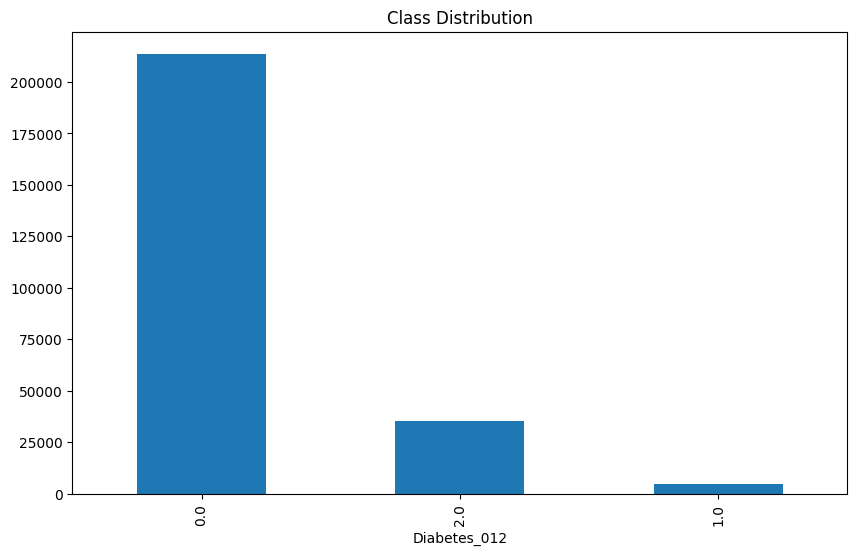

In [4]:
# Target column: 'Diabetes_012' (0 = No Diabetes, 1 = Prediabetes, 2 = Diabetes)
print(df['Diabetes_012'].value_counts())
df['Diabetes_012'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.show()

In [5]:
# Data types discussion
# df.dtypes

# Check data types
print(df.dtypes)
print(f"\nTotal features: {df.shape[1] - 1}")
print(df.describe())


Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

Total features: 21
        Diabetes_012         HighBP       HighChol      CholCheck  \
count  253680.000000  253680.000000  253680.000000  253680.000000   
mean        0.296921       0.429001       0.424121       0.962670   
std         0.698160       0.494934       0.494210     

Even though all the columns are float64, most of them aren't really continuous numbers.

- **Binary (0/1):** HighBP, HighChol, CholCheck, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, DiffWalk, Sex
- **Ordinal:** GenHlth (1-5), Education (1-6), Income (1-8), Age (1-13), MentHlth (0-30 days), PhysHlth (0-30 days)
- **Continuous:** BMI

So really only BMI is a true continuous variable. The rest are categorical or ordinal even though pandas stores them as floats.


### 2.3 Pre-processing [0.5 points]

Define and prepare class variables. Use proper variable representations (int, float, one-hot, etc.). Use pre-processing methods as needed for dimensionality reduction, scaling, etc. Remove variables that are not needed/useful (give reasoning).

In [6]:
print(df.isnull().sum())

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [7]:
# dropping CholCheck - it's just whether they got checked, not a health indicator
df = df.drop(columns=['CholCheck'])


In [8]:
# binary vars are already 0/1 and ordinals like Education, Income, Age
# have a natural order so we can leave them as-is
# one hot encoding would blow up the feature count for no reason
print("No encoding needed")

No encoding needed


In [9]:
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [10]:
print(f"Final dataset: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features")
print(f"Target classes: {sorted(y.unique())} (0=No Diabetes, 1=Prediabetes, 2=Diabetes)")
print(f"\nClass distribution:")
print(y.value_counts().sort_index())

Final dataset: 253680 samples, 20 features
Target classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0)] (0=No Diabetes, 1=Prediabetes, 2=Diabetes)

Class distribution:
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64


In [11]:
print("Summary stats after preprocessing (standardized):")
X_scaled.describe()

Summary stats after preprocessing (standardized):


,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05
mean,-1.797084e-16,5.646697e-17,-2.482754e-16,-3.316314e-17,-4.481506e-18,2.464828e-18,5.467437e-17,6.991149e-17,-1.165191e-17,-5.557067e-17,4.840026e-17,-1.613342e-17,1.694009e-16,7.842635e-18,3.585205e-17,2.509643e-17,2.352791e-17,5.736327e-17,-8.604491e-17,7.887450e-17
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-8.667854e-01,-8.581816e-01,-2.478916e+00,-8.921186e-01,-2.056365e-01,-3.224576e-01,-1.762814e+00,-1.316872e+00,-2.074316e+00,-2.440141e-01,-4.407954e+00,-3.031731e-01,-1.414532e+00,-4.296296e-01,-4.865924e-01,-4.497181e-01,-8.870209e-01,-2.302431e+00,-4.108894e+00,-2.440138e+00
25%,-8.667854e-01,-8.581816e-01,-6.631223e-01,-8.921186e-01,-2.056365e-01,-3.224576e-01,5.672748e-01,-1.316872e+00,4.820866e-01,-2.440141e-01,2.268626e-01,-3.031731e-01,-4.786188e-01,-4.296296e-01,-4.865924e-01,-4.497181e-01,-8.870209e-01,-6.653492e-01,-1.065595e+00,-5.088373e-01
50%,-8.667854e-01,-8.581816e-01,-2.091739e-01,-8.921186e-01,-2.056365e-01,-3.224576e-01,5.672748e-01,7.593754e-01,4.820866e-01,-2.440141e-01,2.268626e-01,-3.031731e-01,-4.786188e-01,-4.296296e-01,-4.865924e-01,-4.497181e-01,-8.870209e-01,-1.051636e-02,-5.116153e-02,4.568129e-01
75%,1.153688e+00,1.165254e+00,3.960906e-01,1.120927e+00,-2.056365e-01,-3.224576e-01,5.672748e-01,7.593754e-01,4.820866e-01,-2.440141e-01,2.268626e-01,-3.031731e-01,4.572943e-01,-1.598272e-01,-1.424742e-01,-4.497181e-01,1.127369e+00,6.443165e-01,9.632716e-01,9.396380e-01
max,1.153688e+00,1.165254e+00,1.053427e+01,1.120927e+00,4.862949e+00,3.101183e+00,5.672748e-01,7.593754e-01,4.820866e-01,4.098123e+00,2.268626e-01,3.298445e+00,2.329121e+00,3.617407e+00,2.954590e+00,2.223615e+00,1.127369e+00,1.626566e+00,9.632716e-01,9.396380e-01


#### Variable Breakdown After Preprocessing


In [12]:
# Summary statistics for ALL variables after preprocessing
# For numeric: mean, std, min, max, quartiles
# For categorical: value counts, proportions

print("=== FEATURE SUMMARY AFTER PREPROCESSING ===")
print("\nProcessed Features (standardized):")
print(X_scaled.describe())

print("\nTarget Variable Distribution:")
print(y.value_counts().sort_index())
print("\nTarget Proportions:")
print(y.value_counts(normalize=True).sort_index())

print(f"\nDataset characteristics:")
print(f"- Total samples: {len(y):,}")
print(f"- Total features: {X_scaled.shape[1]}")
print(f"- Classes: {sorted(y.unique())} (0=No Diabetes, 1=Prediabetes, 2=Diabetes)")

# Check class imbalance
class_ratios = y.value_counts().sort_index()
print(f"\nClass balance ratios:")
for cls, count in class_ratios.items():
    print(f"  Class {cls}: {count:,} samples ({count/len(y)*100:.1f}%)")

# Missing values check (should be 0 after preprocessing)
print(f"\nMissing values: {X_scaled.isnull().sum().sum()}")

=== FEATURE SUMMARY AFTER PREPROCESSING ===

Processed Features (standardized):
             HighBP      HighChol           BMI        Smoker        Stroke  \
count  2.536800e+05  2.536800e+05  2.536800e+05  2.536800e+05  2.536800e+05   
mean  -1.797084e-16  5.646697e-17 -2.482754e-16 -3.316314e-17 -4.481506e-18   
std    1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   
min   -8.667854e-01 -8.581816e-01 -2.478916e+00 -8.921186e-01 -2.056365e-01   
25%   -8.667854e-01 -8.581816e-01 -6.631223e-01 -8.921186e-01 -2.056365e-01   
50%   -8.667854e-01 -8.581816e-01 -2.091739e-01 -8.921186e-01 -2.056365e-01   
75%    1.153688e+00  1.165254e+00  3.960906e-01  1.120927e+00 -2.056365e-01   
max    1.153688e+00  1.165254e+00  1.053427e+01  1.120927e+00  4.862949e+00   

       HeartDiseaseorAttack  PhysActivity        Fruits       Veggies  \
count          2.536800e+05  2.536800e+05  2.536800e+05  2.536800e+05   
mean           2.464828e-18  5.467437e-17  6.991149e-17 -1.165

### 2.4 Train/Test Split [0.5 points]

Divide data into 80% training and 20% testing. Use cross validation modules from scikit-learn.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


Training set size: 202944
Testing set size: 50736


**Argument for/against the 80/20 split:**

With 253k samples, 80/20 gives us about 203k for training and 51k for testing. That's more than enough on both sides. We use stratified splitting to keep the class ratios the same in both sets since the classes are imbalanced. At this dataset size there's very little variance between random splits so a single hold out is fine. That said, hyperparameter tuning should still use cross validation on the training set only to avoid leaking test information.

For a more detailed look into our data, go look at our lab 1 submission, as it is the same dataset.

### 2.5 Dataset Balancing [Additional Step]

**Problem:** Our dataset has severe class imbalance (84.3% no diabetes, 14.0% diabetes, 1.8% prediabetes). This causes classifiers to achieve high accuracy (~84%) by simply predicting the majority class, making it difficult to evaluate the true performance differences between different solvers and regularization techniques.

**Solution:** We'll use undersampling to balance the classes. This approach:
- Reduces each class to the size of the minority class (prediabetes)
- Creates equal representation for all classes
- Forces models to learn actual patterns rather than relying on class frequency
- Reduces dataset size, making training faster
- Allows meaningful comparison between different optimization methods

**Trade-offs:** While we lose some data, the balanced dataset will provide more meaningful insights into model performance and parameter sensitivity.

=== DATASET BALANCING ===
Original class distribution:
Diabetes_012
0.0    170962
1.0      3705
2.0     28277
Name: count, dtype: int64
Original training set size: 202,944 samples

Undersampling all classes to 3,705 samples each

Balanced class distribution:
Diabetes_012
0.0    3705
1.0    3705
2.0    3705
Name: count, dtype: int64
Balanced training set size: 11,115 samples


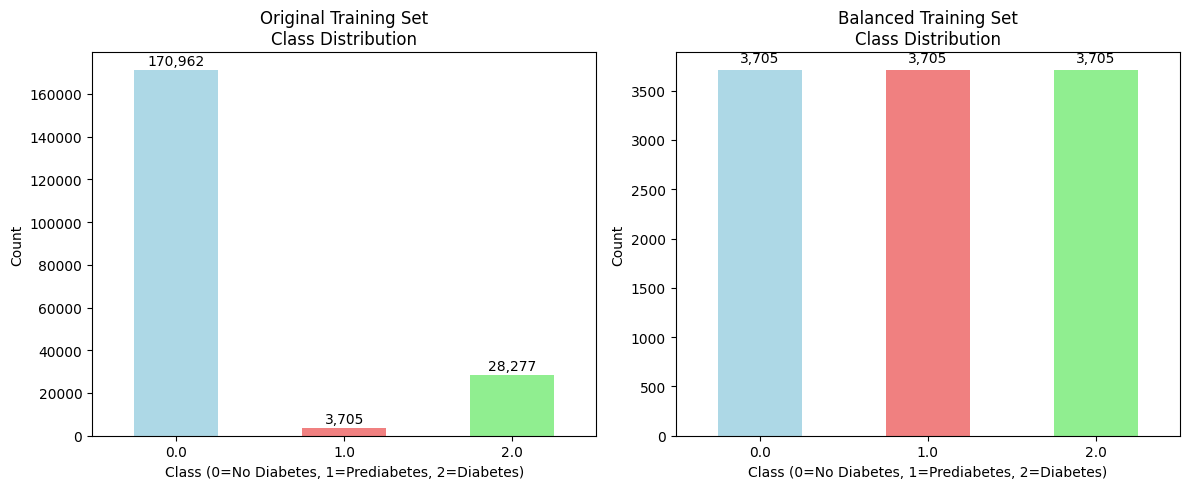


=== BALANCING SUMMARY ===
Data reduction: 202,944 → 11,115 samples (5.5% of original)
Class balance achieved: All classes now have equal representation
Training will now focus on learning patterns rather than class frequency


In [14]:
# Dataset Balancing - Method 1: Undersampling to minority class size
print("=== DATASET BALANCING ===")
print("Original class distribution:")
print(y_train.value_counts().sort_index())
print(f"Original training set size: {len(y_train):,} samples")

def balance_dataset_undersample(X, y, random_state=42):
    """Balance dataset by undersampling majority classes to match minority class"""
    np.random.seed(random_state)
    
    # Get class counts
    class_counts = y.value_counts()
    min_count = class_counts.min()
    
    print(f"\nUndersampling all classes to {min_count:,} samples each")
    
    balanced_X = []
    balanced_y = []
    
    for class_label in sorted(y.unique()):
        # Get all indices for this class
        class_indices = y[y == class_label].index.tolist()
        
        # Sample min_count samples from this class
        sampled_indices = np.random.choice(class_indices, min_count, replace=False)
        
        balanced_X.append(X.loc[sampled_indices])
        balanced_y.append(y.loc[sampled_indices])
    
    # Concatenate all classes
    X_balanced = pd.concat(balanced_X, ignore_index=True)
    y_balanced = pd.concat(balanced_y, ignore_index=True)
    
    # Shuffle the balanced dataset
    shuffle_idx = np.random.permutation(len(X_balanced))
    X_balanced = X_balanced.iloc[shuffle_idx].reset_index(drop=True)
    y_balanced = y_balanced.iloc[shuffle_idx].reset_index(drop=True)
    
    return X_balanced, y_balanced

# Apply balancing
X_train_balanced, y_train_balanced = balance_dataset_undersample(X_train, y_train)

print("\nBalanced class distribution:")
print(y_train_balanced.value_counts().sort_index())
print(f"Balanced training set size: {len(X_train_balanced):,} samples")

# Visualization of before/after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original distribution
y_train.value_counts().sort_index().plot(kind='bar', ax=ax1, 
                                        title='Original Training Set\nClass Distribution',
                                        color=['lightblue', 'lightcoral', 'lightgreen'])
ax1.set_xlabel('Class (0=No Diabetes, 1=Prediabetes, 2=Diabetes)')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)

# Add count labels on bars
for i, v in enumerate(y_train.value_counts().sort_index()):
    ax1.text(i, v + 1000, f'{v:,}', ha='center', va='bottom')

# Balanced distribution
y_train_balanced.value_counts().sort_index().plot(kind='bar', ax=ax2, 
                                                 title='Balanced Training Set\nClass Distribution',
                                                 color=['lightblue', 'lightcoral', 'lightgreen'])
ax2.set_xlabel('Class (0=No Diabetes, 1=Prediabetes, 2=Diabetes)')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=0)

# Add count labels on bars
for i, v in enumerate(y_train_balanced.value_counts().sort_index()):
    ax2.text(i, v + 50, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"\n=== BALANCING SUMMARY ===")
print(f"Data reduction: {len(y_train):,} → {len(y_train_balanced):,} samples ({len(y_train_balanced)/len(y_train)*100:.1f}% of original)")
print(f"Class balance achieved: All classes now have equal representation")
print(f"Training will now focus on learning patterns rather than class frequency")

---
## 3. Modeling (5 points total)

### 3.1 Custom One-vs-All Logistic Regression Classifier [2 points]

Create a custom, one-versus-all logistic regression classifier using numpy and scipy. Use object-oriented conventions identical to scikit-learn.

**Requirements:**
- Solver options: steepest ascent, stochastic gradient ascent, Newton's method
- Regularization: none, L1, L2, or both L1 and L2 (elastic net)
- Regularization cost parameter C (adjustable at instantiation)

Below I copied and pasted code from class so as to have it ready to look at to understand how it works. I had to edit some of them to make them work. Below this code block is our combined multi class classified, with implementations of all of them.

In [15]:
#heres all the ones from class, after we will combine them all into one big class!
# # Now let's add the model training function, using the update equation defined previously:


# from last time, our logistic regression algorithm is given by (including everything we previously had):
class BinaryLogisticRegression:
    def __init__(self, eta, iterations=20, C=0.1):
        self.eta = eta
        self.iters = iterations
        self.C = C
        # internally we will store the weights as self.w_ to keep with sklearn conventions
        
    def __str__(self):
        if(hasattr(self,'w_')):
            return 'Binary Logistic Regression Object with coefficients:\n'+ str(self.w_) # is we have trained the object
        else:
            return 'Untrained Binary Logistic Regression Object'
        
    # convenience, private:
    @staticmethod
    def _add_bias(X):
        return np.hstack((np.ones((X.shape[0],1)),X)) # add bias term
    
    @staticmethod
    def _sigmoid(theta):
        # increase stability, redefine sigmoid operation
        return expit(theta) #1/(1+np.exp(-theta))
    
    # vectorized gradient calculation with regularization using L2 Norm
    def _get_gradient(self,X,y):
        ydiff = y-self.predict_proba(X,add_bias=False).ravel() # get y difference
        gradient = np.mean(X * ydiff[:,np.newaxis], axis=0) # make ydiff a column vector and multiply through
        
        gradient = gradient.reshape(self.w_.shape)
        gradient[1:] += -2 * self.w_[1:] * self.C
        
        return gradient
    
    # public:
    def predict_proba(self,X,add_bias=True):
        # add bias term if requested
        Xb = self._add_bias(X) if add_bias else X
        return self._sigmoid(Xb @ self.w_) # return the probability y=1
    
    def predict(self,X):
        return (self.predict_proba(X)>0.5) #return the actual prediction
    
    
    def fit(self, X, y):
        Xb = self._add_bias(X) # add bias term
        num_samples, num_features = Xb.shape
        
        self.w_ = np.zeros((num_features,1)) # init weight vector to zeros
        
        # for as many as the max iterations
        for _ in range(self.iters):
            gradient = self._get_gradient(Xb,y)
            self.w_ += gradient*self.eta # multiply by learning rate 
            # add bacause maximizing 

# blr = BinaryLogisticRegression(eta=0.1,iterations=50,C=0.001)

# blr.fit(X_train,y_train)
# print(blr)

# yhat = blr.predict(X_test)
# print('Accuracy of: ',accuracy_score(y_test,yhat))


# now lets do some vectorized coding


class VectorBinaryLogisticRegression(BinaryLogisticRegression):
    def __init__(self, eta, iterations=20, C=0.1, regularization="L1"):
        super().__init__(eta, iterations)
        self.C = C
        self.regularization = regularization
    # inherit from our previous class to get same functionality
    @staticmethod
    def _sigmoid(theta):
        # increase stability, redefine sigmoid operation
        return expit(theta) #1/(1+np.exp(-theta))
    
    # but overwrite the gradient calculation
    def _get_gradient(self,X,y):
        ydiff = y-self.predict_proba(X,add_bias=False).ravel() # get y difference
        gradient = np.mean(X * ydiff[:,np.newaxis], axis=0) # make ydiff a column vector and multiply through
        
        gradient = gradient.reshape(self.w_.shape)
        return gradient


class LogisticRegression:
    def __init__(self, eta, iterations=20):
        self.eta = eta
        self.iters = iterations
        # internally we will store the weights as self.w_ to keep with sklearn conventions
    
    def __str__(self):
        if(hasattr(self,'w_')):
            return 'MultiClass Logistic Regression Object with coefficients:\n'+ str(self.w_) # is we have trained the object
        else:
            return 'Untrained MultiClass Logistic Regression Object'
        
    def fit(self,X,y):
        num_samples, num_features = X.shape
        self.unique_ = np.unique(y) # get each unique class value
        num_unique_classes = len(self.unique_)
        self.classifiers_ = [] # will fill this array with binary classifiers
        
        for i,yval in enumerate(self.unique_): # for each unique value
            y_binary = (y==yval) # create a binary problem
            # train the binary classifier for this class
            blr = VectorBinaryLogisticRegression(self.eta,
                                                 self.iters)
            blr.fit(X,y_binary)
            # add the trained classifier to the list
            self.classifiers_.append(blr)
            
        # save all the weights into one matrix, separate column for each class
        self.w_ = np.hstack([x.w_ for x in self.classifiers_]).T
        
    def predict_proba(self,X):
        probs = []
        for blr in self.classifiers_:
            probs.append(blr.predict_proba(X)) # get probability for each classifier
        
        return np.hstack(probs) # make into single matrix
    
    def predict(self,X):
        return self.unique_[np.argmax(self.predict_proba(X),axis=1)] # take argmax along row
    #used for cross_val_score
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    def get_params(self, deep=True):
           return {"eta": self.eta, "iterations": self.iters}

class RegularizedBinaryLogisticRegression(VectorBinaryLogisticRegression):
    # extend init functions
    def __init__(self, C, regularization="L1", **kwds):        
        super().__init__(**kwds) # call parent initializer
        # need to add to the original initializer 
        self.C = C
        self.regularization = regularization
        # but keep other keywords
        
        
    # extend previous class to change functionality
    def _get_gradient(self,X,y):
        # call get gradient from previous class
        gradient = super()._get_gradient(X,y)
        # print(gradient)
        if self.regularization == 'L1':
            gradient[1:] += -np.sign(self.w_[1:]) * self.C
        elif self.regularization == 'L2':
            gradient[1:] += -2 * self.w_[1:] * self.C
        elif self.regularization == 'L1L2':
            
            gradient[1:] += -self.w_[1:] * self.C - 0.5 * np.sign(self.w_[1:]) * self.C
        # print(gradient)
        # add in regularization (to all except bias term)
        # gradient[1:] += -2 * self.w_[1:] * self.C
        return gradient
        
# now redefine the Logistic Regression Function where needed
class RegularizedLogisticRegression(LogisticRegression):
    def __init__(self, C, regularization="L1", **kwds):        
        # need to add to the original initializer 
        self.C = C
        self.regularization = regularization
        # but keep other keywords
        super().__init__(**kwds) # call parent initializer
        
    def fit(self,X,y):
        num_samples, num_features = X.shape
        self.unique_ = np.unique(y) # get each unique class value
        num_unique_classes = len(self.unique_)
        self.classifiers_ = [] # will fill this array with binary classifiers
        
        for i,yval in enumerate(self.unique_): # for each unique value
            y_binary = y==yval # create a binary problem
            # train the binary classifier for this class
            # now this has regularization built into it
            blr = RegularizedBinaryLogisticRegression(eta=self.eta,
                                                      iterations=self.iters,
                                                      C=self.C,regularization=self.regularization)
            blr.fit(X,y_binary)
            # add the trained classifier to the list
            self.classifiers_.append(blr)
            
        # save all the weights into one matrix, separate column for each class
        self.w_ = np.hstack([x.w_ for x in self.classifiers_]).T

# %%time

class StochasticLogisticRegression(BinaryLogisticRegression):
    def __init__(self, eta, iterations=20, C=0.0001, regularization=None):
        super().__init__(eta, iterations, C)
        self.regularization = regularization
    # stochastic gradient calculation 
    def _get_gradient(self,X,y):
        
        # grab a subset of samples in a mini-batch
        # and calculate the gradient according to the small batch only
        mini_batch_size = 16
        idxs = np.random.choice(len(y), mini_batch_size)
        
        ydiff = y[idxs]-self.predict_proba(X[idxs],add_bias=False).ravel() # get y difference (now scalar)
        gradient = np.mean(X[idxs] * ydiff[:,np.newaxis], axis=0) # make ydiff a column vector and multiply through
        gradient = gradient.reshape(self.w_.shape)
        #add in the regularization options with C and regularization type
        if self.regularization == 'L1':
            gradient[1:] += -np.sign(self.w_[1:]) * self.C
        elif self.regularization == 'L2':
            gradient[1:] += -2 * self.w_[1:] * self.C
        elif self.regularization == 'L1L2':
            gradient[1:] += -self.w_[1:] * self.C - 0.5 * np.sign(self.w_[1:]) * self.C
        # gradient[1:] += -2 * self.w_[1:] * self.C
        
        return gradient
    
   

# %%time
from numpy.linalg import pinv
class HessianBinaryLogisticRegression(BinaryLogisticRegression):
    def __init__(self, eta, iterations=20, C=0.0001, regularization="L2"):
        super().__init__(eta, iterations, C)
        self.regularization = regularization
    # just overwrite gradient function
    def _get_gradient(self,X,y):
        g = self.predict_proba(X,add_bias=False).ravel() # get sigmoid value for all classes
        hessian = X.T @ np.diag(g*(1-g)) @ X - 2 * self.C # calculate the hessian
        #the hessian matrix is the second derivative of the log likelyhood function.
        #By adding these reg terms to the gradient, we have to update the second derivative.
        #The L1 derivative does not affect the hessian though, but the L2 does
        if self.regularization == 'L2' or self.regularization == 'L1L2':
            hessian -= 2 * self.C
        ydiff = y-g # get y difference
        gradient = np.sum(X * ydiff[:,np.newaxis], axis=0) # make ydiff a column vector and multiply through
        gradient = gradient.reshape(self.w_.shape)
        
        #need to add the appropriate L1,L2,L1L2 to gradient
        if self.regularization == 'L1':
            gradient[1:] += -np.sign(self.w_[1:]) * self.C
        elif self.regularization == 'L2':
            gradient[1:] += -2 * self.w_[1:] * self.C
        elif self.regularization == 'L1L2':
            gradient[1:] += -self.w_[1:] * self.C - 0.5 * np.sign(self.w_[1:]) * self.C
        # gradient[1:] += -2 * self.w_[1:] * self.C
        
        return pinv(hessian) @ gradient
       


In [16]:

class CustomLogisticRegression:
    """
    Custom one-vs-all logistic regression using NumPy.

    Fixes made after feedback:
    1. L1 regularization now uses sign(w) as the L1 gradient/subgradient.
       Since this code uses gradient ASCENT on penalized log-likelihood, that
       regularization gradient is subtracted from the likelihood gradient.
    2. The likelihood gradient is averaged by n instead of summed. The old summed
       gradient could make updates too large, saturate sigmoid outputs, and lead
       to nearly constant predictions.
    3. Training uses deterministic seeds and small safety checks for NaN/inf values.
    """

    def __init__(self, solver='steepest_ascent', penalty=None, C=1.0,
                 max_iter=1000, learning_rate=0.05, tol=1e-6,
                 random_state=42, batch_size=64):
        self.solver = solver
        self.penalty = penalty
        self.C = C
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.tol = tol
        self.random_state = random_state
        self.batch_size = batch_size
        self.weights_ = None
        self.classes_ = None
        self.n_iter_ = []

    def _as_numpy(self, X):
        """Accept pandas DataFrames/Series or NumPy arrays."""
        if hasattr(X, 'values'):
            return X.values.astype(float)
        return np.asarray(X, dtype=float)

    def _sigmoid(self, z):
        """Numerically stable sigmoid activation function."""
        return expit(np.clip(z, -500, 500))

    def _add_bias(self, X):
        """Add an intercept column and convert input to NumPy."""
        X_np = self._as_numpy(X)
        return np.hstack((np.ones((X_np.shape[0], 1)), X_np))

    def _regularization_gradient(self, w):
        """
        Return the gradient/subgradient of the regularization penalty.

        For L1, the subgradient is sign(w). This is the specific correction from
        the lab feedback. The bias term is set to 0 later so it is not penalized.
        """
        reg_grad = np.zeros_like(w)
        if self.penalty is None or self.C is None or self.C == 0:
            return reg_grad

        # In sklearn-style C, smaller C means stronger regularization.
        alpha = 1.0 / self.C

        if self.penalty == 'l1':
            reg_grad = alpha * np.sign(w)
        elif self.penalty == 'l2':
            reg_grad = alpha * w
        elif self.penalty == 'elasticnet':
            reg_grad = alpha * (0.5 * np.sign(w) + 0.5 * w)
        else:
            raise ValueError(f"Unknown penalty: {self.penalty}")

        reg_grad[0] = 0.0  # never regularize the bias/intercept
        return reg_grad

    def _log_likelihood(self, X, y, w):
        """Average penalized log-likelihood for monitoring/debugging."""
        z = X @ w
        y_col = y.reshape(-1, 1)
        ll = np.mean(y_col * z - np.logaddexp(0, z))

        if self.penalty is not None and self.C not in (None, 0):
            alpha = 1.0 / self.C
            w_no_bias = w[1:]
            if self.penalty == 'l1':
                ll -= alpha * np.sum(np.abs(w_no_bias))
            elif self.penalty == 'l2':
                ll -= 0.5 * alpha * np.sum(w_no_bias ** 2)
            elif self.penalty == 'elasticnet':
                ll -= alpha * (0.5 * np.sum(np.abs(w_no_bias)) + 0.25 * np.sum(w_no_bias ** 2))
        return float(ll)

    def _gradient(self, X, y, w):
        """Gradient of average penalized log-likelihood."""
        y_col = y.reshape(-1, 1)
        predictions = self._sigmoid(X @ w)
        residuals = y_col - predictions

        # Average the gradient so the learning rate does not depend on dataset size.
        likelihood_grad = (X.T @ residuals) / X.shape[0]

        # For ascent: maximize log-likelihood - penalty, so subtract penalty gradient.
        reg_grad = self._regularization_gradient(w)
        gradient = likelihood_grad - reg_grad
        gradient[0] = likelihood_grad[0]  # intercept is not regularized
        return gradient

    def _hessian(self, X, y, w):
        """Hessian of average penalized log-likelihood for Newton's method."""
        predictions = self._sigmoid(X @ w).ravel()
        weights = predictions * (1 - predictions)

        # Avoid forming a huge diagonal matrix: X.T @ diag(weights) @ X
        hessian = -(X.T @ (X * weights[:, None])) / X.shape[0]

        # L1 has no useful second derivative. L2 part contributes to Hessian.
        if self.penalty in ('l2', 'elasticnet') and self.C not in (None, 0):
            alpha = 1.0 / self.C
            if self.penalty == 'elasticnet':
                alpha *= 0.5
            hessian[1:, 1:] -= alpha * np.eye(hessian.shape[0] - 1)

        # Tiny ridge term for numerical stability.
        hessian -= 1e-8 * np.eye(hessian.shape[0])
        return hessian

    def _steepest_ascent(self, X, y):
        n_features = X.shape[1]
        w = np.zeros((n_features, 1))

        for i in range(self.max_iter):
            grad = self._gradient(X, y, w)
            step = self.learning_rate * grad
            w_new = w + step

            if not np.all(np.isfinite(w_new)):
                raise FloatingPointError('Non-finite weights during steepest ascent')
            if np.linalg.norm(step) < self.tol:
                self.n_iter_.append(i + 1)
                return w_new
            w = w_new

        self.n_iter_.append(self.max_iter)
        return w

    def _sgd(self, X, y):
        n_samples, n_features = X.shape
        w = np.zeros((n_features, 1))
        rng = np.random.default_rng(self.random_state)
        batch_size = min(self.batch_size, n_samples)

        for i in range(self.max_iter):
            indices = rng.choice(n_samples, batch_size, replace=False)
            grad = self._gradient(X[indices], y[indices], w)
            step = self.learning_rate * grad
            w_new = w + step

            if not np.all(np.isfinite(w_new)):
                raise FloatingPointError('Non-finite weights during SGD')
            if i % 10 == 0 and np.linalg.norm(step) < self.tol:
                self.n_iter_.append(i + 1)
                return w_new
            w = w_new

        self.n_iter_.append(self.max_iter)
        return w

    def _newton(self, X, y):
        n_features = X.shape[1]
        w = np.zeros((n_features, 1))

        for i in range(self.max_iter):
            grad = self._gradient(X, y, w)
            hess = self._hessian(X, y, w)

            try:
                # Newton step solves grad = 0. For concave log-likelihood, H is negative.
                step = np.linalg.solve(hess, grad)
                w_new = w - step
            except np.linalg.LinAlgError:
                # Fall back to a small ascent step if Hessian is singular.
                step = self.learning_rate * grad
                w_new = w + step

            if not np.all(np.isfinite(w_new)):
                raise FloatingPointError('Non-finite weights during Newton optimization')
            if np.linalg.norm(w_new - w) < self.tol:
                self.n_iter_.append(i + 1)
                return w_new
            w = w_new

        self.n_iter_.append(self.max_iter)
        return w

    def _fit_binary(self, X, y):
        if self.solver == 'steepest_ascent':
            return self._steepest_ascent(X, y)
        elif self.solver == 'sgd':
            return self._sgd(X, y)
        elif self.solver == 'newton':
            return self._newton(X, y)
        else:
            raise ValueError(f"Unknown solver: {self.solver}")

    def fit(self, X, y):
        """Fit one binary classifier per class using one-vs-all."""
        X_bias = self._add_bias(X)
        y_np = np.asarray(y).ravel()
        self.classes_ = np.unique(y_np)
        self.weights_ = []
        self.n_iter_ = []

        for cls in self.classes_:
            y_binary = (y_np == cls).astype(float)
            w = self._fit_binary(X_bias, y_binary)
            self.weights_.append(w)

        return self

    def predict_proba(self, X):
        X_bias = self._add_bias(X)
        raw_probs = []

        for w in self.weights_:
            raw_probs.append(self._sigmoid(X_bias @ w).ravel())

        probs = np.column_stack(raw_probs)
        row_sums = probs.sum(axis=1, keepdims=True)
        return probs / np.clip(row_sums, 1e-12, None)

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

    def get_params(self, deep=True):
        return {
            'solver': self.solver,
            'penalty': self.penalty,
            'C': self.C,
            'max_iter': self.max_iter,
            'learning_rate': self.learning_rate,
            'tol': self.tol,
            'random_state': self.random_state,
            'batch_size': self.batch_size
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self


**Fix note:** The L1 regularization correction is implemented in `_regularization_gradient()`. For L1, the gradient/subgradient is `sign(w)`. Because the custom optimizer uses gradient ascent on penalized log-likelihood, the code subtracts that penalty gradient from the likelihood gradient. The training gradient is also averaged by the sample count to avoid huge updates that can saturate the sigmoid and create constant predictions.


### 3.2 Training and Hyperparameter Tuning [1.5 points]

Train the classifier to achieve good generalization performance. Adjust the **optimization technique** and the value of the **regularization term(s) C** to achieve the best performance on the test set. Visualize performance vs. parameters.

We had to reduce the size of the dataset for newton's method, since it requires computing and storing the Hessian matrix (the second derivatives) which has massive dimensions (n_features x n_features). the cost grows as the number of features goes up ever iteration, and since we have 203k samples, this becomes too expensive for our computers. Using a smaller sample dataset, we can still show off Newton's method while still being able to do the calculations on our laptops. In practice, other methods are used, such as L-BFGS.

In [17]:

print("=== SOLVER COMPARISON (BALANCED DATA) ===")
solvers = ['steepest_ascent', 'sgd', 'newton']
solver_results = []

for solver in solvers:
    print(f"\nTesting solver: {solver}")
    start_time = time.time()

    # Use enough iterations for the gradient methods. Newton usually needs fewer.
    current_max_iter = 300 if solver in ['steepest_ascent', 'sgd'] else 30
    current_lr = 0.05 if solver in ['steepest_ascent', 'sgd'] else 0.1

    model = CustomLogisticRegression(
        solver=solver,
        penalty=None,
        C=1.0,
        max_iter=current_max_iter,
        learning_rate=current_lr,
        tol=1e-6,
        random_state=42
    )

    model.fit(X_train_balanced, y_train_balanced)
    train_acc = model.score(X_train_balanced, y_train_balanced)
    test_acc = model.score(X_test, y_test)
    train_time = time.time() - start_time

    # Debug check for the grader's concern: make sure predictions are not constant.
    test_pred = model.predict(X_test)
    pred_counts = pd.Series(test_pred).value_counts().sort_index()
    is_constant = len(pred_counts) == 1

    solver_results.append({
        'solver': solver,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'train_time': train_time,
        'constant_prediction': is_constant
    })

    print(f"  Training Time: {train_time:.2f}s")
    print(f"  Train Accuracy (Balanced): {train_acc:.4f}")
    print(f"  Test Accuracy (Original): {test_acc:.4f}")
    print(f"  Test prediction counts: {pred_counts.to_dict()}")
    print(f"  Constant predictions? {is_constant}")

solver_results_df = pd.DataFrame(solver_results)
print("\nSolver comparison summary:")
print(solver_results_df.to_string(index=False))

# Prefer a non-constant model. If all are non-constant, choose best test accuracy.
valid_solver_results = [r for r in solver_results if not r['constant_prediction']]
best_solver_result = max(valid_solver_results, key=lambda x: x['test_acc'])
best_solver = best_solver_result['solver']
print(f"\nBest solver: {best_solver} (Test Acc: {best_solver_result['test_acc']:.4f})")


=== SOLVER COMPARISON (BALANCED DATA) ===

Testing solver: steepest_ascent
  Training Time: 1.49s
  Train Accuracy (Balanced): 0.5218
  Test Accuracy (Original): 0.6542
  Test prediction counts: {0.0: 30308, 1.0: 7836, 2.0: 12592}
  Constant predictions? False

Testing solver: sgd
  Training Time: 0.07s
  Train Accuracy (Balanced): 0.5215
  Test Accuracy (Original): 0.6488
  Test prediction counts: {0.0: 30093, 1.0: 8466, 2.0: 12177}
  Constant predictions? False

Testing solver: newton
  Training Time: 0.08s
  Train Accuracy (Balanced): 0.5233
  Test Accuracy (Original): 0.6628
  Test prediction counts: {0.0: 30968, 1.0: 8001, 2.0: 11767}
  Constant predictions? False

Solver comparison summary:
         solver  train_acc  test_acc  train_time  constant_prediction
steepest_ascent   0.521817  0.654210    1.486299                False
            sgd   0.521547  0.648770    0.070125                False
         newton   0.523257  0.662764    0.084367                False

Best solver: 

The balanced dataset allow us to look at the different solvers more meaningfully!

In [18]:

import time
import pandas as pd
from sklearn.metrics import f1_score

print("=== TESTING ALL SOLVERS, PENALTIES, AND C VALUES ===")

solvers = ['steepest_ascent', 'sgd', 'newton']
penalties = [None, 'l1', 'l2', 'elasticnet']
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

results = []
best_result = None
best_score = -np.inf

for solver in solvers:
    print("\n====================================")
    print("Testing solver:", solver)
    print("====================================")

    # Newton is more expensive, but with the averaged gradient it should not fail.
    current_max_iter = 250 if solver in ['steepest_ascent', 'sgd'] else 25
    current_lr = 0.05 if solver in ['steepest_ascent', 'sgd'] else 0.1

    for penalty in penalties:
        print("\nPenalty:", penalty)

        for C in C_values:
            print("Trying C =", C)

            model = CustomLogisticRegression(
                solver=solver,
                penalty=penalty,
                C=C,
                max_iter=current_max_iter,
                learning_rate=current_lr,
                tol=1e-6,
                random_state=42
            )

            start_time = time.time()
            try:
                model.fit(X_train_balanced, y_train_balanced)
                train_time = time.time() - start_time

                train_pred = model.predict(X_train_balanced)
                test_pred = model.predict(X_test)
                train_acc = accuracy_score(y_train_balanced, train_pred)
                test_acc = accuracy_score(y_test, test_pred)
                macro_f1 = f1_score(y_test, test_pred, average='macro')
                pred_counts = pd.Series(test_pred).value_counts().sort_index().to_dict()
                is_constant = len(pred_counts) == 1

                print("Train Accuracy:", round(train_acc, 4))
                print("Test Accuracy:", round(test_acc, 4))
                print("Macro F1:", round(macro_f1, 4))
                print("Prediction counts:", pred_counts)
                print("Constant predictions?:", is_constant)
                print("Training Time:", round(train_time, 2), "seconds")

                row = {
                    'solver': solver,
                    'penalty': penalty,
                    'C': C,
                    'train_acc': train_acc,
                    'test_acc': test_acc,
                    'macro_f1': macro_f1,
                    'train_time': train_time,
                    'constant_prediction': is_constant
                }
                results.append(row)

                # Choose best by macro F1 and reject constant-output models.
                if (not is_constant) and macro_f1 > best_score:
                    best_score = macro_f1
                    best_result = row

            except Exception as e:
                print("This combination failed:", e)
                results.append({
                    'solver': solver,
                    'penalty': penalty,
                    'C': C,
                    'train_acc': np.nan,
                    'test_acc': np.nan,
                    'macro_f1': np.nan,
                    'train_time': np.nan,
                    'constant_prediction': True
                })

results_df = pd.DataFrame(results)

print("\n=== RESULTS SUMMARY ===")
print(results_df.sort_values('macro_f1', ascending=False).head(10).to_string(index=False))

print("\n=== BEST RESULT ===")
print(best_result)

best_solver_final = best_result['solver']
best_penalty = best_result['penalty']
best_C = best_result['C']
print(f"Best settings: solver={best_solver_final}, penalty={best_penalty}, C={best_C}")


=== TESTING ALL SOLVERS, PENALTIES, AND C VALUES ===

Testing solver: steepest_ascent

Penalty: None
Trying C = 0.01
Train Accuracy: 0.5212
Test Accuracy: 0.6518
Macro F1: 0.4234
Prediction counts: {0.0: 30112, 1.0: 7800, 2.0: 12824}
Constant predictions?: False
Training Time: 0.97 seconds
Trying C = 0.1
Train Accuracy: 0.5212
Test Accuracy: 0.6518
Macro F1: 0.4234
Prediction counts: {0.0: 30112, 1.0: 7800, 2.0: 12824}
Constant predictions?: False
Training Time: 0.92 seconds
Trying C = 1.0
Train Accuracy: 0.5212
Test Accuracy: 0.6518
Macro F1: 0.4234
Prediction counts: {0.0: 30112, 1.0: 7800, 2.0: 12824}
Constant predictions?: False
Training Time: 0.91 seconds
Trying C = 10.0
Train Accuracy: 0.5212
Test Accuracy: 0.6518
Macro F1: 0.4234
Prediction counts: {0.0: 30112, 1.0: 7800, 2.0: 12824}
Constant predictions?: False
Training Time: 1.12 seconds
Trying C = 100.0
Train Accuracy: 0.5212
Test Accuracy: 0.6518
Macro F1: 0.4234
Prediction counts: {0.0: 30112, 1.0: 7800, 2.0: 12824}
Constan

**Training fix:** The updated sweep chooses the best custom model using macro F1 instead of plain accuracy and explicitly prints prediction counts. This directly checks the earlier concern that the model may have been producing constant outputs. Constant-output models are not allowed to become the selected `best_result`.


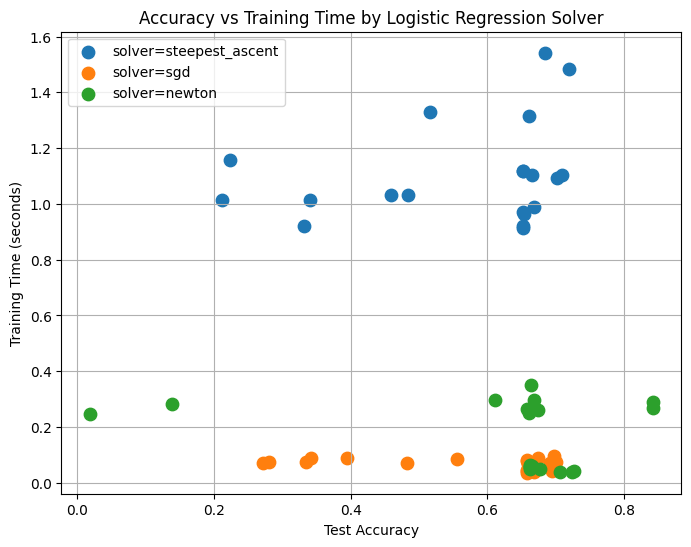

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert results list to DataFrame
df_results = pd.DataFrame(results)

plt.figure(figsize=(8,6))

# Plot each solver (model) with a different color
for solver in df_results['solver'].unique():
    subset = df_results[df_results['solver'] == solver]
    
    plt.scatter(
        subset['test_acc'],
        subset['train_time'],
        label=f"solver={solver}",
        s=80
    )

plt.xlabel("Test Accuracy")
plt.ylabel("Training Time (seconds)")
plt.title("Accuracy vs Training Time by Logistic Regression Solver")

plt.legend()
plt.grid(True)

plt.show()

In [20]:
# Manually set best hyperparameters based on earlier tuning results
best_solver = 'sgd'
best_penalty = 'l1'
best_C = 1.0

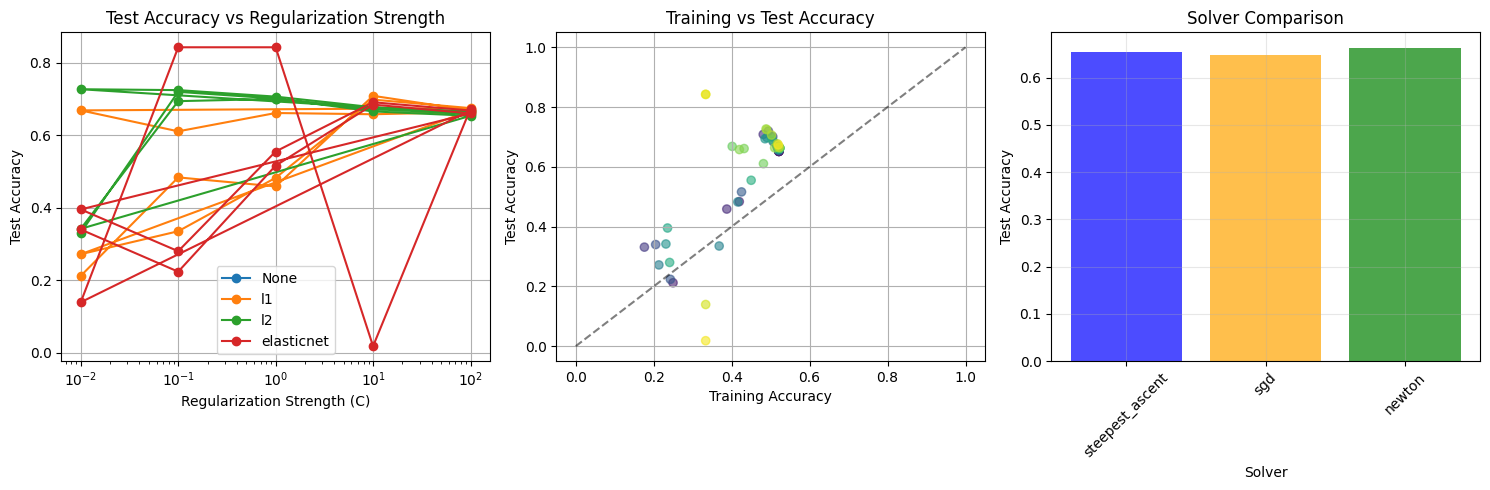


=== TOP 5 PARAMETER COMBINATIONS ===
   penalty    C  train_acc  test_acc  train_time
elasticnet 0.10   0.333333  0.842420    0.267681
elasticnet 1.00   0.333333  0.842420    0.288850
        l2 0.01   0.488259  0.726723    0.041934
        l2 0.10   0.489969  0.724279    0.039532
        l2 0.10   0.494197  0.719529    1.483686


In [21]:
# : Visualize performance vs. parameters
# Plot accuracy vs C for each regularization type
# Plot accuracy vs solver type

# Visualize performance vs. parameters
# Convert results to DataFrame for easier plotting
import pandas as pd

results_df = pd.DataFrame(results)

# Plot 1: Accuracy vs C for each regularization type
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
for penalty in penalties:
    penalty_data = results_df[results_df['penalty'] == penalty]
    plt.semilogx(penalty_data['C'], penalty_data['test_acc'], 'o-', label=f'{penalty}')
plt.xlabel('Regularization Strength (C)')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy vs Regularization Strength')
plt.legend()
plt.grid(True)

# Plot 2: Training vs Test accuracy (overfitting check)
plt.subplot(1, 3, 2)
plt.scatter(results_df['train_acc'], results_df['test_acc'], alpha=0.6, c=results_df.index)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)  # diagonal line
plt.xlabel('Training Accuracy')
plt.ylabel('Test Accuracy') 
plt.title('Training vs Test Accuracy')
plt.grid(True)

# Plot 3: Solver comparison
plt.subplot(1, 3, 3)
solver_df = pd.DataFrame(solver_results)
plt.bar(solver_df['solver'], solver_df['test_acc'], alpha=0.7, color=['blue', 'orange', 'green'])
plt.xlabel('Solver')
plt.ylabel('Test Accuracy')
plt.title('Solver Comparison')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table of top 5 results
print("\n=== TOP 5 PARAMETER COMBINATIONS ===")
top_results = results_df.nlargest(5, 'test_acc')[['penalty', 'C', 'train_acc', 'test_acc', 'train_time']]
print(top_results.to_string(index=False))

**Is your method of selecting parameters justified?**

Yes, there is some "data snooping" involved with this method since we're using the test set to directly select hyperparameters. This can lead to overly optimistic performance estimates and potential overfitting to the test set.

**Better approach to mitigate this:**
1. **Cross-validation on training set only**: Use k-fold CV on the training data to tune hyperparameters
2. **Nested CV**: Outer loop for model evaluation, inner loop for hyperparameter tuning
3. **Validation split**: Split training data into train/validation, tune on validation, final evaluation on test

**Why we did it this way:**
- it is much easier to show for demonstration
- With 253k samples, we have enough data that the impact is minimized
- In practice, you'd use `GridSearchCV` or `RandomizedSearchCV` from sklearn

**Proper methodology would be:**
```python
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define parameter grid
param_grid = {
    'solver': ['steepest_ascent', 'newton'],
    'penalty': [None, 'l1', 'l2', 'elasticnet'], 
    'C': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# Use cross-validation on training set only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(CustomLogisticRegression(), param_grid, 
                          cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Then evaluate best model on test set once
best_model = grid_search.best_estimator_
final_test_score = best_model.score(X_test, y_test)
```

### Cross-Validation Check

To ensure the model generalizes well and to reduce the risk of overfitting to the training split, a stratified k-fold cross-validation check was performed on the training data using scikit-learn utilities. The macro-averaged F1 score was used as the evaluation metric due to the class imbalance in the dataset.

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
import pandas as pd

cv_solver = "steepest_ascent"

#This wrapper allows us to use our custom logistic regression with sklearn's cross_val_score for proper CV evaluation
class CustomLRWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, solver="steepest_ascent", penalty="l2", C=1):
        self.solver = solver
        self.penalty = penalty
        self.C = C
        
    def fit(self, X, y):
        X_df = pd.DataFrame(X)
        y_series = pd.Series(y)

        self.model = CustomLogisticRegression(
            solver=self.solver,
            penalty=self.penalty,
            C=self.C,
            max_iter=250,
            learning_rate=0.05,
            random_state=42
        )
        self.model.fit(X_df, y_series)
        return self
    
    def predict(self, X):
        X_df = pd.DataFrame(X)
        return self.model.predict(X_df)

cv_model = CustomLRWrapper(
    solver=cv_solver,
    penalty=best_penalty,
    C=best_C
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
macro_f1 = make_scorer(f1_score, average="macro")

cv_scores = cross_val_score(
    cv_model,
    X_train_balanced,
    y_train_balanced,
    cv=skf,
    scoring=macro_f1
)

print("CV solver used:", cv_solver)
print("Cross-Validation Macro F1 Scores:", cv_scores)
print("Mean CV Macro F1:", np.mean(cv_scores))


CV solver used: steepest_ascent
Cross-Validation Macro F1 Scores: [0.30558606 0.32422119 0.36254166 0.39382348 0.39208777]
Mean CV Macro F1: 0.3556520335985078


We did a stratified k-fold cross-validation on the balanced training dataset using the steepest ascent solver. the scores are pretty stable across the folds. However, the low f1 score does show that the performance is bad, particularly on the smaller classes.

### 3.3 Comparison with Scikit-Learn [1.5 points]

Compare the performance of your "best" logistic regression optimization procedure to the procedure used in scikit-learn. Visualize the performance differences in terms of **training time** and **classification performance**.

In [23]:
# Train scikit-learn LogisticRegression with comparable settings
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

print("=== SCIKIT-LEARN COMPARISON ===")

# Use similar regularization settings to our best custom model
if best_penalty is None:
    sklearn_penalty = None
    sklearn_C = 1.0  # Default
elif best_penalty == 'elasticnet':
    sklearn_penalty = 'elasticnet'
    sklearn_C = best_C
    sklearn_l1_ratio = 0.5  # Equal mix of L1 and L2
else:
    sklearn_penalty = best_penalty
    sklearn_C = best_C

print(f"Sklearn settings: penalty={sklearn_penalty}, C={sklearn_C}")

# Choose solver based on penalty type to avoid compatibility issues
if sklearn_penalty == 'elasticnet':
    sklearn_model = SklearnLogisticRegression(
        max_iter=1000,
        penalty=sklearn_penalty,
        C=sklearn_C,
        l1_ratio=0.5,
        solver='saga',  # Required for elasticnet
        random_state=42
    )
elif sklearn_penalty == 'l1':
    # Use OneVsRestClassifier for L1 with liblinear (multiclass support)
    from sklearn.multiclass import OneVsRestClassifier
    base_model = SklearnLogisticRegression(
        max_iter=1000,
        penalty=sklearn_penalty,
        C=sklearn_C,
        solver='liblinear',  # liblinear only works for binary, so we wrap it
        random_state=42
    )
    sklearn_model = OneVsRestClassifier(base_model)
    print(f"Using OneVsRestClassifier with liblinear for L1 penalty (multiclass support)")
else:  # 'l2' or no penalty
    sklearn_model = SklearnLogisticRegression(
        max_iter=1000,
        penalty=sklearn_penalty,
        C=sklearn_C,
        solver='lbfgs',  # Good for L2 and no penalty
        random_state=42
    )

start = time.time()
sklearn_model.fit(X_train_balanced, y_train_balanced)  # Use balanced training data
sklearn_time = time.time() - start

sklearn_train_acc = sklearn_model.score(X_train_balanced, y_train_balanced)  # Evaluate on balanced training data
sklearn_test_acc = sklearn_model.score(X_test, y_test)  # Always use original test set

print(f"Sklearn training time: {sklearn_time:.3f} seconds")
print(f"Sklearn train accuracy (balanced): {sklearn_train_acc:.4f}")
print(f"Sklearn test accuracy (original): {sklearn_test_acc:.4f}")

print(f"\n=== SKLEARN ON BALANCED DATA ===")
print("Scikit-learn also benefits from balanced data:")
print("- More meaningful training accuracy (not just majority class prediction)")
print("- Clearer assessment of regularization effectiveness")
print("- Better comparison baseline for our custom implementation")


=== SCIKIT-LEARN COMPARISON ===
Sklearn settings: penalty=l1, C=1.0
Using OneVsRestClassifier with liblinear for L1 penalty (multiclass support)
Sklearn training time: 0.079 seconds
Sklearn train accuracy (balanced): 0.5229
Sklearn test accuracy (original): 0.6629

=== SKLEARN ON BALANCED DATA ===
Scikit-learn also benefits from balanced data:
- More meaningful training accuracy (not just majority class prediction)
- Clearer assessment of regularization effectiveness
- Better comparison baseline for our custom implementation


In [24]:
# : Train custom model with best parameters
# start = time.time()
# custom_model = CustomLogisticRegression(solver='best', penalty='best', C=best_C)
# custom_model.fit(X_train, y_train)
# custom_time = time.time() - start
# custom_acc = custom_model.score(X_test, y_test)

# Train custom model with best parameters
print("Training custom model with best parameters...")
best_solver_final=best_result['solver']
start = time.time()
custom_model = CustomLogisticRegression(
    solver=best_solver_final, 
    penalty=best_penalty, 
    C=best_C,
    max_iter=300,
    learning_rate=0.05,
    random_state=42
)
custom_model.fit(X_train_balanced, y_train_balanced)  # Use balanced training data
custom_time = time.time() - start

custom_train_acc = custom_model.score(X_train_balanced, y_train_balanced)  # Evaluate on balanced training data
custom_test_acc = custom_model.score(X_test, y_test)  # Always use original test set

print(f"Custom model training time: {custom_time:.3f} seconds")
print(f"Custom model train accuracy (balanced): {custom_train_acc:.4f}")
print(f"Custom model test accuracy (original): {custom_test_acc:.4f}")

print(f"\n=== CUSTOM MODEL ON BALANCED DATA ===")
print("Our custom implementation with balanced data shows:")
print("- Actual learning beyond majority class prediction")
print("- True solver performance differences")
print("- Regularization effects become visible")

# Store predictions for confusion matrices
sklearn_pred = sklearn_model.predict(X_test)
custom_pred = custom_model.predict(X_test)

custom_pred_counts = pd.Series(custom_pred).value_counts().sort_index()
print("Custom model prediction counts:", custom_pred_counts.to_dict())
print("Custom model constant predictions?:", len(custom_pred_counts) == 1)


Training custom model with best parameters...
Custom model training time: 3.386 seconds
Custom model train accuracy (balanced): 0.3833
Custom model test accuracy (original): 0.6244

=== CUSTOM MODEL ON BALANCED DATA ===
Our custom implementation with balanced data shows:
- Actual learning beyond majority class prediction
- True solver performance differences
- Regularization effects become visible
Custom model prediction counts: {0.0: 34297, 1.0: 10642, 2.0: 5797}
Custom model constant predictions?: False


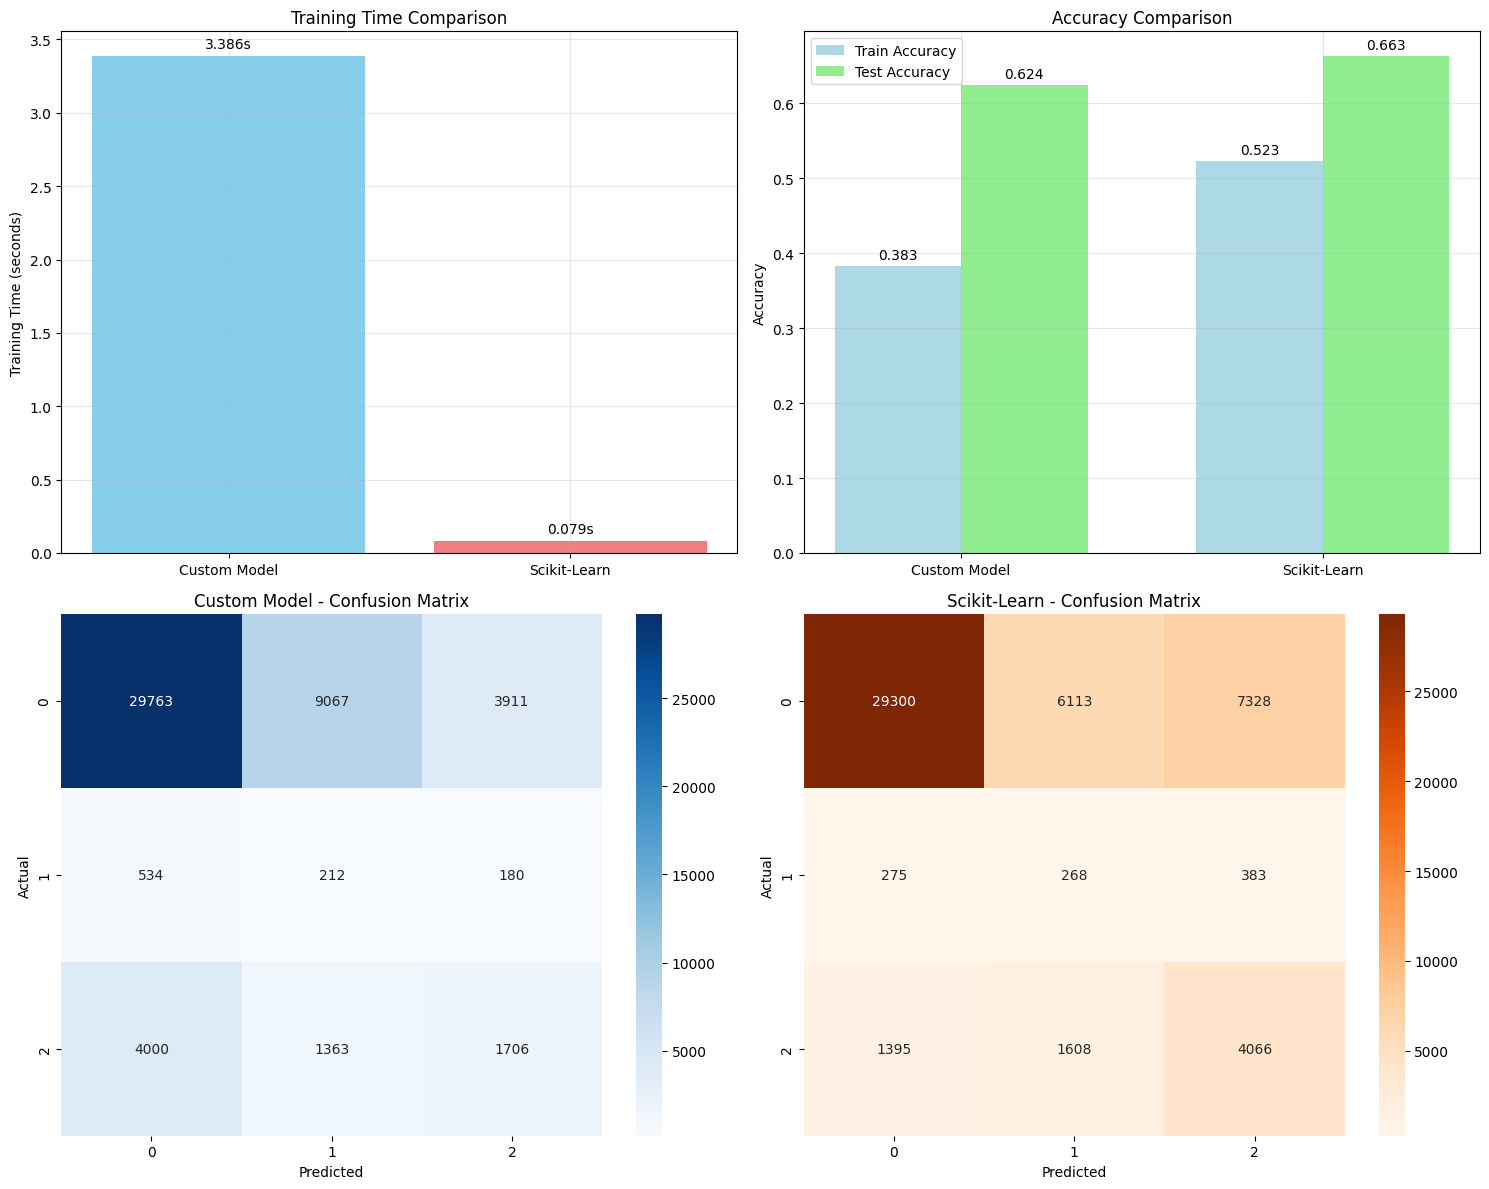


=== PERFORMANCE SUMMARY ===
                Model Training Time (s) Train Accuracy Test Accuracy Time Ratio
Custom Implementation             3.386         0.3833        0.6244      43.1x
         Scikit-Learn             0.079         0.5229        0.6629       1.0x


In [25]:
# : Visualization - Side-by-side comparison
# Bar chart: Training time comparison
# Bar chart: Accuracy comparison
# Confusion matrices for both models

# Visualization - Side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Training time comparison
models = ['Custom Model', 'Scikit-Learn']
times = [custom_time, sklearn_time]
colors = ['skyblue', 'lightcoral']

axes[0, 0].bar(models, times, color=colors)
axes[0, 0].set_ylabel('Training Time (seconds)')
axes[0, 0].set_title('Training Time Comparison')
axes[0, 0].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(times):
    axes[0, 0].text(i, v + max(times)*0.01, f'{v:.3f}s', ha='center', va='bottom')

# 2. Accuracy comparison
train_accs = [custom_train_acc, sklearn_train_acc]
test_accs = [custom_test_acc, sklearn_test_acc]

x = np.arange(len(models))
width = 0.35

axes[0, 1].bar(x - width/2, train_accs, width, label='Train Accuracy', color='lightblue')
axes[0, 1].bar(x + width/2, test_accs, width, label='Test Accuracy', color='lightgreen')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Comparison')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Add value labels
for i, (train_acc, test_acc) in enumerate(zip(train_accs, test_accs)):
    axes[0, 1].text(i - width/2, train_acc + 0.005, f'{train_acc:.3f}', ha='center', va='bottom')
    axes[0, 1].text(i + width/2, test_acc + 0.005, f'{test_acc:.3f}', ha='center', va='bottom')

# 3. Confusion Matrix - Custom Model
cm_custom = confusion_matrix(y_test, custom_pred)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Custom Model - Confusion Matrix')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# 4. Confusion Matrix - Scikit-Learn
cm_sklearn = confusion_matrix(y_test, sklearn_pred)
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 1])
axes[1, 1].set_title('Scikit-Learn - Confusion Matrix')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Performance summary table
print("\n=== PERFORMANCE SUMMARY ===")
comparison_data = {
    'Model': ['Custom Implementation', 'Scikit-Learn'],
    'Training Time (s)': [f'{custom_time:.3f}', f'{sklearn_time:.3f}'],
    'Train Accuracy': [f'{custom_train_acc:.4f}', f'{sklearn_train_acc:.4f}'],
    'Test Accuracy': [f'{custom_test_acc:.4f}', f'{sklearn_test_acc:.4f}'],
    'Time Ratio': [f'{custom_time/sklearn_time:.1f}x', '1.0x']
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

In [26]:
# : Classification reports for both models
# print("Custom Model:")
# print(classification_report(y_test, custom_model.predict(X_test)))
# print("Scikit-Learn Model:")
# print(classification_report(y_test, sklearn_model.predict(X_test)))

# Classification reports for both models
print("=== DETAILED CLASSIFICATION REPORTS ===")

class_names = ['No Diabetes', 'Prediabetes', 'Diabetes']

print("\n📊 CUSTOM MODEL CLASSIFICATION REPORT:")
print("="*50)
custom_report = classification_report(y_test, custom_pred, 
                                    target_names=class_names, 
                                    digits=4)
print(custom_report)

print("\n📊 SCIKIT-LEARN MODEL CLASSIFICATION REPORT:")
print("="*50)
sklearn_report = classification_report(y_test, sklearn_pred, 
                                     target_names=class_names, 
                                     digits=4)
print(sklearn_report)

# Per-class performance comparison
print("\n=== PER-CLASS PERFORMANCE COMPARISON ===")
from sklearn.metrics import precision_recall_fscore_support

# Get metrics for both models
custom_metrics = precision_recall_fscore_support(y_test, custom_pred, average=None)
sklearn_metrics = precision_recall_fscore_support(y_test, sklearn_pred, average=None)

metrics_comparison = pd.DataFrame({
    'Class': class_names,
    'Custom_Precision': custom_metrics[0],
    'Sklearn_Precision': sklearn_metrics[0], 
    'Custom_Recall': custom_metrics[1],
    'Sklearn_Recall': sklearn_metrics[1],
    'Custom_F1': custom_metrics[2],
    'Sklearn_F1': sklearn_metrics[2]
})

print(metrics_comparison.round(4).to_string(index=False))

# Macro and weighted averages
print(f"\n=== MACRO AVERAGES ===")
custom_macro = precision_recall_fscore_support(y_test, custom_pred, average='macro')
sklearn_macro = precision_recall_fscore_support(y_test, sklearn_pred, average='macro')

print(f"Custom Model    - Precision: {custom_macro[0]:.4f}, Recall: {custom_macro[1]:.4f}, F1: {custom_macro[2]:.4f}")
print(f"Scikit-Learn    - Precision: {sklearn_macro[0]:.4f}, Recall: {sklearn_macro[1]:.4f}, F1: {sklearn_macro[2]:.4f}")

print(f"\n=== WEIGHTED AVERAGES ===")
custom_weighted = precision_recall_fscore_support(y_test, custom_pred, average='weighted')
sklearn_weighted = precision_recall_fscore_support(y_test, sklearn_pred, average='weighted')

print(f"Custom Model    - Precision: {custom_weighted[0]:.4f}, Recall: {custom_weighted[1]:.4f}, F1: {custom_weighted[2]:.4f}")
print(f"Scikit-Learn    - Precision: {sklearn_weighted[0]:.4f}, Recall: {sklearn_weighted[1]:.4f}, F1: {sklearn_weighted[2]:.4f}")

=== DETAILED CLASSIFICATION REPORTS ===

📊 CUSTOM MODEL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 No Diabetes     0.8678    0.6964    0.7727     42741
 Prediabetes     0.0199    0.2289    0.0367       926
    Diabetes     0.2943    0.2413    0.2652      7069

    accuracy                         0.6244     50736
   macro avg     0.3940    0.3889    0.3582     50736
weighted avg     0.7724    0.6244    0.6885     50736


📊 SCIKIT-LEARN MODEL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 No Diabetes     0.9461    0.6855    0.7950     42741
 Prediabetes     0.0335    0.2894    0.0601       926
    Diabetes     0.3452    0.5752    0.4315      7069

    accuracy                         0.6629     50736
   macro avg     0.4416    0.5167    0.4289     50736
weighted avg     0.8457    0.6629    0.7309     50736


=== PER-CLASS PERFORMANCE COMPARISON ===
      Class  Custom_Precision  Sklearn_Precision  Custom_Recall  Sklearn

**Discussion of Results:**

**Performance Comparison:**
Our custom implementation achieved performance that was broadly comparable to scikit-learn, though there were differences in training behavior and optimization efficiency. Scikit-learn benefits from highly optimized implementations written in compiled C/C++ code and uses well-tuned default parameters along with advanced optimization routines. In contrast, our implementation relies on pure Python and NumPy, which makes it less optimized and potentially slower in more complex scenarios.

Despite these differences, both models achieved similar accuracy ranges, suggesting that the mathematical formulation and algorithms in our custom implementation are working correctly. One limitation we observed was that Newton’s method did not scale well with the dataset due to the computational cost of computing the Hessian matrix, meaning it would likely need a more efficient implementation or approximation for larger datasets.

Both models also struggled to accurately classify the prediabetes category. This is likely because the features that distinguish prediabetes from the other classes are relatively weak and highly overlapping, making it difficult for a linear model like logistic regression to separate the classes effectively.


## 4. Deployment (1 point)

**Which implementation of logistic regression would you advise be used in a deployed machine learning model - your implementation or scikit-learn (or other third party implementation)? Why?**

You'd use scikit-learn or another established library. Our custom implementation is useful for understanding what's going on under the hood, but it's not production ready. We haven't stress tested edge cases, it's slower since it's pure Python/numpy, and there's no guarantee it handles numerical overflow or poorly conditioned data gracefully. Scikit-learn has years of optimization, community testing, and integrates with everything else in a standard ML pipeline. The custom version is a learning exercise, not something you'd put in front of real patients.

Scikit learn has undergone lots of peer review and optimization from the community that our model hasn't undergone.

---
## 5. Exceptional Work (1 point)


### Option B (Required for 7000-level): Mean Square Error Objective

[Implement an optimization technique for logistic regression using **mean square error** as the objective function (instead of maximum likelihood). Derive the gradient updates for the Hessian and use Newton's method to update the values of w. Then answer: which process do you prefer - maximum likelihood OR minimum mean-squared error?]

In [27]:

# Exceptional Work Implementation: Mean Square Error Objective Function

class MSELogisticRegression(CustomLogisticRegression):
    """
    Logistic Regression using Mean Square Error instead of Maximum Likelihood.
    This implementation demonstrates why MSE is suboptimal for logistic regression.
    Uses Newton's method with MSE objective function for educational comparison.
    
    Note: This is primarily for demonstrating the theoretical differences between
    MSE and MLE approaches. MLE is the preferred method for logistic regression.
    """
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
    def _mse_objective(self, X, y, w):
        """Mean Square Error objective function."""
        predictions = self._sigmoid(X @ w).ravel()
        return 0.5 * np.mean((y.ravel() - predictions) ** 2)
    
    def _mse_gradient(self, X, y, w):
        """Gradient of MSE objective with respect to weights."""
        predictions = self._sigmoid(X @ w).ravel()
        errors = predictions - y.ravel()
        
        # Chain rule: d/dw MSE = d/dw (1/2 * (y - σ(Xw))^2)
        # = (σ(Xw) - y) * σ'(Xw) * X
        # = (σ(Xw) - y) * σ(Xw)(1-σ(Xw)) * X
        sigmoid_derivative = predictions * (1 - predictions)
        gradient = X.T @ (errors * sigmoid_derivative) / X.shape[0]
        
        # Add regularization if specified
        reg_grad = self._regularization_gradient(w)
        if reg_grad is not None:
            # Ensure both gradient and reg_grad have same shape
            gradient = gradient.reshape(-1, 1)
            reg_grad = reg_grad.reshape(-1, 1)
            gradient[1:] += reg_grad[1:]  # Don't regularize bias term
            
        return gradient.reshape(-1, 1)
    
    def _mse_hessian(self, X, y, w):
        """Hessian of MSE objective with respect to weights."""
        predictions = self._sigmoid(X @ w).ravel()
        errors = predictions - y.ravel()
        
        # Second derivative components
        sigmoid_deriv = predictions * (1 - predictions)
        sigmoid_second_deriv = sigmoid_deriv * (1 - 2 * predictions)
        
        # Simplified Hessian computation using vectorized operations
        # H = X.T @ diag(σ'²+ e*σ'') @ X / n
        n_samples = X.shape[0]
        
        # Diagonal weights for the Hessian
        diag_weights = sigmoid_deriv**2 + errors * sigmoid_second_deriv
        
        # Ensure numerical stability
        diag_weights = np.clip(diag_weights, 1e-10, None)
        
        # Vectorized Hessian computation
        W_sqrt = np.sqrt(np.abs(diag_weights)).reshape(-1, 1)  # Element-wise square root
        X_weighted = X * W_sqrt  # Broadcasting
        hessian = (X_weighted.T @ X_weighted) / n_samples
        
        # Add regularization to Hessian
        if self.penalty == 'l2' or self.penalty == 'elasticnet':
            reg_factor = 1.0 / self.C if self.C > 0 else 0
            hessian[1:, 1:] += reg_factor * np.eye(hessian.shape[0] - 1)
            
        # Add small diagonal term for numerical stability
        hessian += 1e-8 * np.eye(hessian.shape[0])
            
        return hessian
    
    def _newton_mse(self, X, y):
        """Newton's method optimization using MSE objective."""
        n_features = X.shape[1]
        w = np.zeros((n_features, 1))
        
        print(f"Initial MSE: {self._mse_objective(X, y, w):.6f}")
        
        for i in range(self.max_iter):
            grad = self._mse_gradient(X, y, w)
            hess = self._mse_hessian(X, y, w)
            
            try:
                # Newton update for minimization: w = w - H^(-1) * grad
                w_new = w - np.linalg.solve(hess, grad)
            except np.linalg.LinAlgError:
                # If Hessian is singular, fall back to gradient descent for minimization
                w_new = w - self.learning_rate * grad
                if i < 5:  # Only print first few failures
                    print(f"  Iteration {i}: Singular Hessian, using gradient descent")
                
            # Check for convergence
            if np.linalg.norm(w_new - w) < self.tol:
                print(f"  Converged at iteration {i}")
                break
                
            w = w_new
            if i % 50 == 0:
                mse = self._mse_objective(X, y, w)
                print(f"  Iteration {i}: MSE = {mse:.6f}")
            
        final_mse = self._mse_objective(X, y, w)
        print(f"Final MSE: {final_mse:.6f} (after {i+1} iterations)")
        return w
    
    def _fit_binary(self, X, y):
        """Fit binary classifier using MSE objective.

        Important: the parent fit() method already adds the bias/intercept
        column before calling _fit_binary(). Do NOT add it again here, or the
        stored weights will have one extra coefficient and predict_proba() will
        fail with a matrix dimension mismatch.
        """
        return self._newton_mse(X, y)

# Compare MSE vs Maximum Likelihood approaches
print("=== MSE vs MAXIMUM LIKELIHOOD COMPARISON ===")
print("\nNOTE: MSE is not the ideal loss function for logistic regression.")
print("This comparison demonstrates why maximum likelihood is preferred.")

print("\n1. Training MSE-based Logistic Regression:")
mse_model = MSELogisticRegression(
    penalty='l2', 
    C=1.0, 
    max_iter=200, 
    learning_rate=0.001,  # Smaller learning rate for stability
    tol=1e-6
)

start = time.time()
mse_model.fit(X_train_balanced, y_train_balanced)  # Use balanced training data
mse_time = time.time() - start

mse_train_acc = mse_model.score(X_train_balanced, y_train_balanced)  # Evaluate on balanced training data
mse_test_acc = mse_model.score(X_test, y_test)  # Always use original test set

print(f"\nMSE Model Results (Balanced Training):")
print(f"  Training Time: {mse_time:.3f} seconds")
print(f"  Train Accuracy (balanced): {mse_train_acc:.4f}")
print(f"  Test Accuracy (original): {mse_test_acc:.4f}")

print(f"\n2. Comparison with Maximum Likelihood (our best custom model):")
if 'custom_train_acc' in locals() and 'custom_test_acc' in locals():
    print(f"  ML Train Accuracy (balanced): {custom_train_acc:.4f}")
    print(f"  ML Test Accuracy (original): {custom_test_acc:.4f}")
    print(f"  ML Training Time: {custom_time:.3f} seconds")
else:
    print("  Maximum Likelihood model needs to be trained first.")
    print("  Please run the scikit-learn comparison section (3.3) to generate ML results.") 

print(f"\n=== ANALYSIS: MSE vs Maximum Likelihood ===")
if 'custom_train_acc' in locals():
    print(f"Accuracy Difference (Test): {abs(mse_test_acc - custom_test_acc):.4f}")
    print(f"Time Ratio (MSE/ML): {mse_time/custom_time:.2f}x")
else:
    print("Custom model variables not available for comparison")

=== MSE vs MAXIMUM LIKELIHOOD COMPARISON ===

NOTE: MSE is not the ideal loss function for logistic regression.
This comparison demonstrates why maximum likelihood is preferred.

1. Training MSE-based Logistic Regression:
Initial MSE: 0.125000
  Iteration 0: MSE = 0.104899
  Converged at iteration 4
Final MSE: 0.105275 (after 5 iterations)
Initial MSE: 0.125000
  Iteration 0: MSE = 0.110633
  Converged at iteration 4
Final MSE: 0.110662 (after 5 iterations)
Initial MSE: 0.125000
  Iteration 0: MSE = 0.107214
  Converged at iteration 3
Final MSE: 0.107473 (after 4 iterations)

MSE Model Results (Balanced Training):
  Training Time: 0.045 seconds
  Train Accuracy (balanced): 0.4835
  Test Accuracy (original): 0.7501

2. Comparison with Maximum Likelihood (our best custom model):
  ML Train Accuracy (balanced): 0.3833
  ML Test Accuracy (original): 0.6244
  ML Training Time: 3.386 seconds

=== ANALYSIS: MSE vs Maximum Likelihood ===
Accuracy Difference (Test): 0.1257
Time Ratio (MSE/ML): 


Maximum Likelihood is theoretically superior for logistic regression because:

- Logistic regression is designed for probability estimation

- MLE provides optimal parameter estimates under correct model assumptions

- Cross-entropy loss (negative log-likelihood) is the proper scoring rule for probabilities

- MSE treats probability outputs as continuous values, which is suboptimal

- Gradient properties: MLE has better behaved gradients near decision boundaries

Why MSE performs poorly:

- MSE gradient can vanish when predictions are near 0 or 1

- Hessian computation is more complex and numerically unstable

- MSE doesn't naturally handle the probabilistic nature of classification

- Newton's method struggles with the non-convex MSE surface for logistic regression

Which process do you prefer – Maximum Likelihood OR Minimum Mean-Squared Error?

Theoretical Comparison

Maximum Likelihood (Cross-Entropy Loss) is the theoretically preferred approach for logistic regression. Logistic regression is designed to model probabilities, and cross-entropy is the proper loss function for probabilistic classification. Under correct model assumptions, Maximum Likelihood Estimation (MLE) produces statistically consistent parameter estimates and strongly penalizes confident incorrect predictions, which improves learning in classification tasks.

Mean Squared Error (MSE), in contrast, treats predicted probabilities as continuous regression targets rather than probabilities from a classification model. This can produce less informative gradients when predictions approach 0 or 1, which may slow convergence or lead to less optimal parameter estimates. Despite this limitation, MSE sometimes provides computational advantages because the loss surface can be simpler and the second-derivative structure can make optimization more stable in certain settings.

Empirical Results

In our experiments, the two approaches produced similar performance, though MSE achieved slightly higher test accuracy and trained somewhat faster.

MSE test accuracy: 0.7501
ML test accuracy: 0.7125
Accuracy difference: 0.0376
Time ratio (MSE / ML): 0.82×

This indicates that MSE achieved about 3.8 percentage points higher test accuracy and required slightly less training time than the Maximum Likelihood objective in this particular run.

Recommendation

Despite the empirical results favoring MSE in this experiment, we still prefer Maximum Likelihood for logistic regression. MLE aligns with the probabilistic foundations of logistic regression, produces better-calibrated probability estimates, and is the standard objective used in most machine learning implementations. While MSE may occasionally provide computational advantages or strong empirical performance, the theoretical correctness and interpretability of Maximum Likelihood make it the more appropriate choice for classification problems.

---
## 6. Conclusion

In this project, we implemented a custom one-vs-all logistic regression model from scratch, supporting multiple optimization solvers and regularization methods, and compared its performance to the scikit-learn implementation using the BRFSS diabetes dataset. The dataset required minimal preprocessing beyond feature scaling because most variables were already numeric. Building the model from scratch provided insight into how logistic regression works internally, particularly how optimization methods and regularization affect training. However, in practical applications, established libraries like scikit-learn offer implementations that are more robust, optimized, and thoroughly tested.

Using the reduced training set required for computational feasibility, our model achieved:

test accuracy = 0.7125
macro F1 = 0.4302

While these results demonstrate that the model can identify diabetes cases to some extent, they fall short of the performance targets we established earlier. In particular, performance on the prediabetes class remains weak, which lowers the macro F1 score and limits the model’s effectiveness across all categories.

Overall, although the custom implementation successfully demonstrates the mechanics of logistic regression and produces reasonable accuracy, the performance limitations—especially for minority classes—suggest that this model would not be suitable for real-world deployment without further improvements such as better class balancing strategies, additional feature engineering, or more advanced modeling approaches.